# Download de bibliotecas

In [1]:
!pip install numpy==1.23.5 pandas==2.2.2

In [ ]:
!pip install pmdarima

  Using cached pmdarima-2.0.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 24.0 MB/s eta 0:00:00


# Importando dados

In [ ]:
import pandas as pd
import os
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

caminho_dados = '/content/drive/Shareddrives/IC - Otimizacao computacional para inflacao/Dados/dados_USA'

# Listar os arquivos dentro da pasta "Dados"
arquivos_dados = os.listdir(caminho_dados)

print(arquivos_dados)


Mounted at /content/drive
['Untitled0.ipynb', 'dados_macroeconomicos_usa.csv']


In [ ]:
file_path = os.path.join(caminho_dados, 'dados_macroeconomicos_usa.csv')

df = pd.read_csv(file_path, index_col='DATE', parse_dates=True)
df.drop(columns=['Unnamed: 0'], inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 180 entries, 2010-01-01 to 2024-12-01
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Inflacao_CPI                 180 non-null    float64
 1   Inflacao_CPI_Core            180 non-null    float64
 2   PCE_Core                     180 non-null    float64
 3   Desemprego                   180 non-null    float64
 4   Desemprego_menos_27_semanas  180 non-null    float64
 5   Taxa_Juros_Fed               180 non-null    float64
 6   Emprego_Total_Nao_Agricola   180 non-null    int64  
 7   Permissoes_Construcao        180 non-null    int64  
 8   Salario_Medio                180 non-null    float64
 9   Salario_Medio_Real_Hora      180 non-null    float64
 10  Producao_Industrial          180 non-null    float64
 11  Capacidade_Instalada         180 non-null    float64
 12  PCE                          180 non-null    float64
 13  D

In [ ]:
df.head()

,Inflacao_CPI,Inflacao_CPI_Core,PCE_Core,Desemprego,Desemprego_menos_27_semanas,Taxa_Juros_Fed,Emprego_Total_Nao_Agricola,Permissoes_Construcao,Salario_Medio,Salario_Medio_Real_Hora,Producao_Industrial,Capacidade_Instalada,PCE,Deflator_PIB,PIB_Real,PIB,Indice_Dolar,TIPS_5_anos_nominal,TIPS_5_anos_infl_ajustado
DATE,,,,,,,,,,,,,,,,,,,
2010-01-01,216.687,220.633,89.368,9.8,22.3,0.11,129802,636,22.41,18.88,89.1897,70.7084,90.177,89.036,16582.710,14764.610,87.8890,2.65,0.52
2010-02-01,216.741,220.731,89.446,9.8,22.4,0.13,129705,650,22.46,18.91,89.5046,71.1021,90.177,89.036,16582.710,14764.610,89.8344,2.38,0.39
2010-03-01,217.631,220.783,89.579,9.9,21.7,0.16,129865,687,22.46,18.92,90.1356,71.7572,90.177,89.036,16582.710,14764.610,90.5404,2.28,0.45
2010-04-01,218.009,220.822,89.625,9.9,20.7,0.20,130120,637,22.49,18.96,90.4607,72.1775,90.317,89.471,16743.162,14980.193,89.7470,2.59,0.74
2010-05-01,218.178,220.962,89.724,9.6,21.1,0.20,130643,575,22.51,19.01,91.7014,73.3305,90.317,89.471,16743.162,14980.193,91.1109,2.47,0.47


# Funcoes auxiliares

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

# Funções auxiliares

def make_stationary(df, max_diff=5):
    """Torna a série temporal estacionária através de diferenciação."""
    df_diff = df.copy()
    for i in range(1, max_diff + 1):
        stationary = True
        for column in df_diff.columns:
            if not check_stationarity(df_diff[[column]]):
                stationary = False
                df_diff[[column]] = df_diff[[column]].diff().fillna(method='ffill').fillna(method='bfill')
        if stationary:
            print(f"Série estacionária após {i-1} diferenciações.")
            return df_diff.dropna()
    raise ValueError("A série não se tornou estacionária após o número máximo de diferenciações.")

def check_stationarity(series, significance_level=0.05):
    """Verifica se a série é estacionária usando o teste ADF."""
    from statsmodels.tsa.stattools import adfuller
    result = adfuller(series.dropna())
    return result[1] < significance_level

def plot_forecasts(y_test, final_forecast, title='Previsão Dinâmica'):
    """Plota as previsões comparadas com os valores reais."""
    plt.figure(figsize=(15, 3))
    plt.plot(y_test.index, y_test, label='Valores Reais', color='blue')
    plt.plot(y_test.index, final_forecast, label='Previsão', color='orange')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# ARIMAX

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Função principal
def executar_modelo_arimax(df, exogenous_vars, tecnica_nome):

    # Tornar o DataFrame estacionário
    df_stationary = make_stationary(df[['Inflacao_CPI'] + exogenous_vars])

    # Dividir em treino e teste
    train_size = int(len(df_stationary) * 0.8)
    train, test = df_stationary.iloc[:train_size], df_stationary.iloc[train_size:]

    # Variável dependente e exógenas
    y_train = train['Inflacao_CPI']
    y_test = test['Inflacao_CPI']
    X_train = train[exogenous_vars]
    X_test = test[exogenous_vars]

    # Ajustar modelo ARIMAX com auto_arima
    arimax_model = auto_arima(y_train, exogenous=X_train, seasonal=False, trace=True,
                               error_action='ignore', suppress_warnings=True)
    arimax_order = arimax_model.order

    # Previsão dinâmica com atualização a cada passo
    dynamic_arimax_forecast = []
    history_y = list(y_train)
    history_X = list(X_train.values)

    for t in range(len(y_test)):
        # Ajusta SARIMAX com histórico até o ponto atual
        model = SARIMAX(history_y, exog=np.array(history_X), order=arimax_order)
        fitted_model = model.fit(disp=False)

        # Previsão de 1 passo à frente
        next_x = X_test.iloc[t].values.reshape(1, -1)
        forecast = fitted_model.forecast(steps=1, exog=next_x)
        dynamic_arimax_forecast.append(forecast[0])

        # Atualiza histórico com valores reais
        history_y.append(y_test.iloc[t])
        history_X.append(X_test.iloc[t].values)

    # Converter previsões para DataFrame
    final_forecast_df = pd.DataFrame(dynamic_arimax_forecast, index=y_test.index, columns=['Final_Forecast'])
    final_forecast_df.to_csv('arimax_pred.csv')

    # Salvar o modelo original do auto_arima (pode ser útil para reuso)
    joblib.dump(arimax_model, 'arimax_model.pkl')

    # Cálculo dos resíduos
    residuals = y_test.values - dynamic_arimax_forecast
    residuals_df = pd.DataFrame(residuals, index=y_test.index, columns=['Residuals'])
    residuals_df.to_csv('arimax_res.csv')

    # Métricas de desempenho
    mse = mean_squared_error(y_test, dynamic_arimax_forecast)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, dynamic_arimax_forecast)
    mape = np.mean(np.abs((y_test - dynamic_arimax_forecast) / y_test))
    r2 = r2_score(y_test, dynamic_arimax_forecast)

    print(f'MAE: {mae:.6f}')
    print(f'MSE: {mse:.6f}')
    print(f'RMSE: {rmse:.6f}')
    print(f'MAPE: {mape:.6f}')

    # Plotar resultados
    plot_forecasts(y_test, dynamic_arimax_forecast, title=tecnica_nome)

# Implementacao

ARIMAX-GA

Série estacionária após 2 diferenciações.
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=274.464, Time=0.78 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=312.107, Time=0.10 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=314.050, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=313.963, Time=0.41 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=275.658, Time=0.38 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=272.474, Time=0.39 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=285.076, Time=0.94 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=300.652, Time=0.13 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=274.459, Time=0.54 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=290.889, Time=0.12 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=276.391, Time=1.55 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.79 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0]          
Total fit time: 7.265 seconds
MAE: 0.842945
MSE: 1.289541
RMSE: 1.135580
MAPE: 1.783741


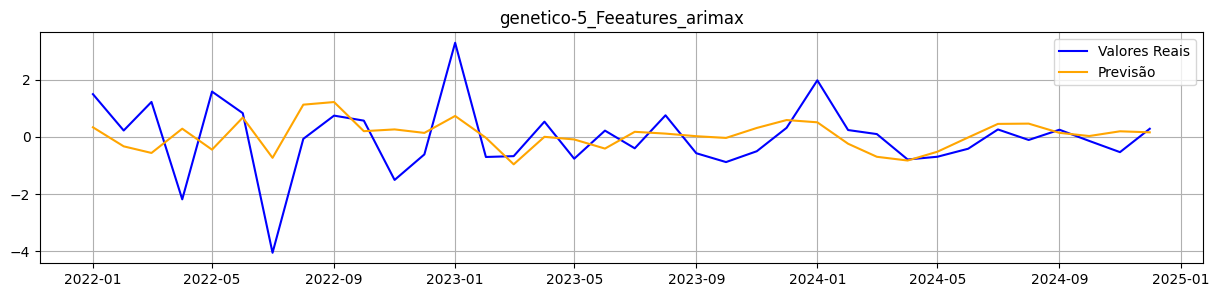

In [ ]:
exogenous_vars= ['Inflacao_CPI_Core', 'Desemprego_menos_27_semanas', 'Taxa_Juros_Fed', 'Permissoes_Construcao', 'Capacidade_Instalada', 'PCE', 'TIPS_5_anos_nominal']
executar_modelo_arimax(df,exogenous_vars,'genetico-5_Feeatures_arimax')

Arimax - PSO

Série estacionária após 2 diferenciações.
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=274.464, Time=0.13 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=312.107, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=314.050, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=313.963, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=275.658, Time=0.13 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=272.474, Time=0.10 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=285.076, Time=0.09 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=300.652, Time=0.05 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=274.459, Time=0.15 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=290.889, Time=0.05 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=276.391, Time=0.29 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.38 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0]          
Total fit time: 1.532 seconds
MAE: 0.849512
MSE: 1.403477
RMSE: 1.184684
MAPE: 1.421287


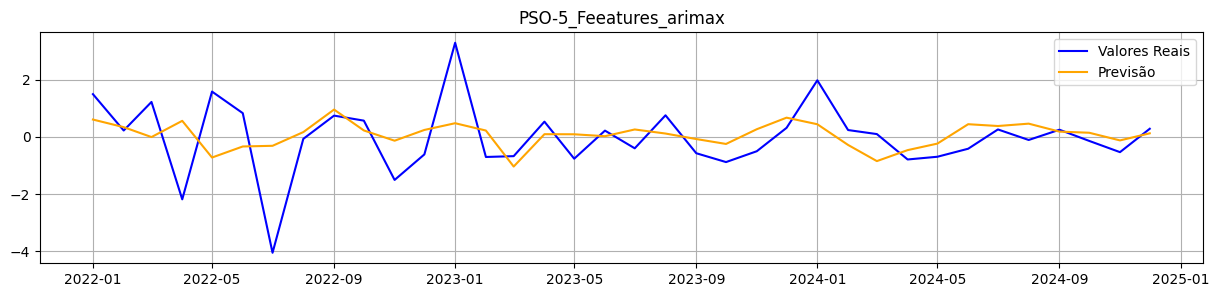

In [ ]:
exogenous_vars= ['Emprego_Total_Nao_Agricola', 'PIB_Real', 'PIB', 'Indice_Dolar', 'TIPS_5_anos_infl_ajustado']
executar_modelo_arimax(df,exogenous_vars,'PSO-5_Feeatures_arimax')


In [13]:
def get_features(df, exclude):
    """
    Retorna uma lista com todas as colunas do DataFrame, exceto as especificadas.

    Parâmetros:
    - df: pandas.DataFrame
    - exclude: string ou lista de strings com os nomes das colunas a excluir

    Retorno:
    - List[str]: lista de colunas restantes
    """
    if isinstance(exclude, str):
        exclude = [exclude]
    return df.columns.difference(exclude).tolist()


Série estacionária após 2 diferenciações.
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=274.464, Time=0.16 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=312.107, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=314.050, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=313.963, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=275.658, Time=0.12 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=272.474, Time=0.10 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=285.076, Time=0.09 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=300.652, Time=0.04 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=274.459, Time=0.15 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=290.889, Time=0.05 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=276.391, Time=0.29 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.36 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0]          
Total fit time: 1.499 seconds
MAE: 0.826561
MSE: 1.369447
RMSE: 1.170234
MAPE: 1.759756


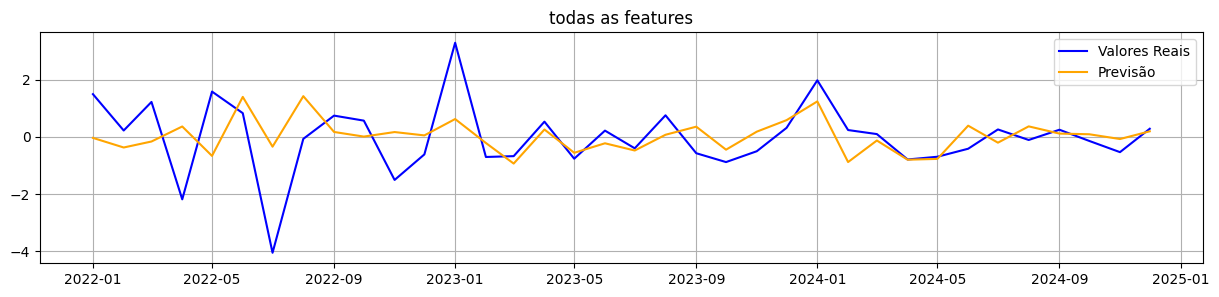

In [14]:
exogenous_vars= get_features(df, 'Inflacao_CPI')
executar_modelo_arimax(df,exogenous_vars,'todas as features')
